In [123]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

## Dataset generation

In [124]:
df=pd.read_csv(r"C:\Users\vithu\OneDrive\Desktop\IISERB'26\Student behaviour modelling\master_NT_Mood_Intervention.csv")
df_clean=df.dropna(subset=["Context"]).copy()
df_clean["NT_post_Timestamp"]=pd.to_datetime(df_clean['NT_post_Timestamp'])
df_clean["NT_post_Timestamp"].dtype

datetime64[ns, UTC]

In [125]:
df_clean['NT_post_Timestamp'] = df_clean['NT_post_Timestamp'].dt.tz_localize(None)

df_filtered=df_clean[df_clean['NT_post_Timestamp'].between('2025-03-30','2025-04-05')]

In [126]:
ong_activity=df_filtered["Context"].unique()
surr=df_filtered["Social Context"].unique()
p_id=df_filtered['Participant_Id'].unique()
interventions = df_filtered["Intervention"].unique()

In [127]:
# We'll pick first seven days and randomly pick 30 ppl to create a activity frequency chart

rng=np.random.default_rng()
ppl_list=rng.choice(p_id,size=30,replace=False)

df_filtered_select= df_filtered[df_filtered['Participant_Id'].isin(ppl_list)]

### Getting prior for Activity

In [128]:
context_counts=df_filtered_select["Context"].value_counts()

print(ong_activity)
freq=[0]*len(ong_activity)
for k,v in context_counts.items():
    for i in range(len(ong_activity)):
        if ong_activity[i]==k:
            freq[i]=v/(7*30) # 7 days and 30 people were chosen

print(freq)

['Relaxing' 'Eating' 'Attending Lecture' 'Studying' 'Walking' 'Standing'
 'Exercise' 'Running' 'E-Rick/Auto' 'Cycling']
[2.204761904761905, 0.6571428571428571, 0.7952380952380952, 1.8952380952380952, 0.7857142857142857, 0.48095238095238096, 0.13333333333333333, 0.06190476190476191, 0.06666666666666667, 0.01904761904761905]


## Getting prior for Social context

In [129]:
social_context_counts=df_filtered_select["Social Context"].value_counts()

print(surr)
soc_freq=[0]*len(surr)
for k,v in social_context_counts.items():
    for i in range(len(surr)):
        if surr[i]==k:
            soc_freq[i]=v/(7*30) # 7 days and 30 people were chosen

print(soc_freq)

['Alone' 'With Someone (Not Engaged in Conversation)'
 'With Someone (Engaged in Conversation)']
[4.238095238095238, 1.2571428571428571, 1.6047619047619048]


In [130]:
num_people = 100
days_per_person = 14 
activities_per_day = 14

total_records = num_people * days_per_person * activities_per_day

# --- 2. Normalize BOTH Priors ---
# Ensure both arrays sum perfectly to 1.0 to prevent NumPy errors
act_priors = np.array(freq)
act_priors = act_priors / act_priors.sum()

soc_priors = np.array(soc_freq)
soc_priors = soc_priors / soc_priors.sum()

# --- 3. Generate the Data ---
rng = np.random.default_rng()

# Generate Activities using the activity priors
synthetic_activities = rng.choice(ong_activity, size=total_records, p=act_priors)

# Generate Social Contexts using the new social priors
synthetic_social = rng.choice(surr, size=total_records, p=soc_priors)

# Create Participant IDs, Days, and Slots (Same structure as before)
p_ids = [f"Syn_{str(i).zfill(3)}" for i in range(1, num_people + 1)]
synthetic_ids = np.repeat(p_ids, days_per_person * activities_per_day)

single_person_days = np.repeat(np.arange(1, days_per_person + 1), activities_per_day)
synthetic_days = np.tile(single_person_days, num_people)

synthetic_slots = np.tile(np.arange(1, activities_per_day + 1), num_people * days_per_person)

# --- 4. Build the Final DataFrame ---
synthetic_df = pd.DataFrame({
    'Participant_Id': synthetic_ids,
    'Day': synthetic_days,
    'Activity_Slot': synthetic_slots,
    'Context': synthetic_activities,
    'Social_Context': synthetic_social
})

# Verify the output
print(f"Total synthetic rows created: {len(synthetic_df)}\n")
print(synthetic_df.head(15))

Total synthetic rows created: 19600

   Participant_Id  Day  Activity_Slot            Context  \
0         Syn_001    1              1  Attending Lecture   
1         Syn_001    1              2           Studying   
2         Syn_001    1              3  Attending Lecture   
3         Syn_001    1              4           Relaxing   
4         Syn_001    1              5           Relaxing   
5         Syn_001    1              6             Eating   
6         Syn_001    1              7           Relaxing   
7         Syn_001    1              8           Standing   
8         Syn_001    1              9            Running   
9         Syn_001    1             10  Attending Lecture   
10        Syn_001    1             11           Relaxing   
11        Syn_001    1             12           Relaxing   
12        Syn_001    1             13           Studying   
13        Syn_001    1             14           Studying   
14        Syn_001    2              1           Relaxing   

  

In [131]:
# 1. Define the 16x10 matrix directly from the provided table.
# Rows = 16 Interventions,Columns = 10 Activities
priors_16x10 = np.array([
    [0.842,0.842,0.947,0.526,0.368,0.789,0.474,0.842,0.158,0.972],# Breathing Exercise
    [0.211,0.579,0.972,0.972,0.368,0.947,0.316,0.579,0.895,0.972],# Calling loved ones
    [0.526,0.789,0.972,0.789,0.474,0.789,0.421,0.895,0.526,0.972],# Close your eyes
    [0.895,0.972,0.972,0.895,0.263,0.895,0.316,0.920,0.421,0.972],# Neck Rolls
    [0.158,0.000,0.972,0.632,0.000,0.474,0.000,0.842,0.972,0.789],# Eating something
    [0.053,0.579,0.737,0.000,0.000,0.789,0.368,0.895,0.105,0.789],# Go for a walk
    [0.368,0.000,0.789,0.158,0.000,0.053,0.053,0.632,0.053,0.421],# Journal Writing
    [0.211,0.972,0.972,0.947,0.895,0.972,0.867,0.789,0.842,0.972],# Listening to Music
    [0.684,0.421,0.947,0.474,0.211,0.368,0.211,0.789,0.368,0.842],# List of positive things
    [0.842,0.947,0.972,0.972,0.842,0.972,0.842,0.895,0.947,0.972],# Observe surroundings
    [0.263,0.105,0.842,0.474,0.000,0.263,0.053,0.368,0.263,0.737],# Play mobile game
    [0.421,0.316,0.947,0.842,0.158,0.684,0.158,0.526,0.632,0.895],# Old memories gallery
    [0.368,0.947,0.972,0.158,0.053,0.737,0.368,0.895,0.105,0.947],# Stretching
    [0.158,0.053,0.972,0.842,0.211,0.789,0.000,0.368,0.842,0.842],# Watching funny videos
    [0.158,0.579,0.842,0.684,0.211,0.579,0.105,0.526,0.632,0.789],# Motivational video
    [0.632,0.211,0.895,0.368,0.000,0.158,0.000,0.789,0.158,0.684]  # Writing Down a Worry
])

# 2. Transpose the matrix so it becomes (10 Activities,16 Interventions)
priors_10x16 = priors_16x10.T

# 3. Set the confidence scale (C = alpha + beta)
C = 20

# 4. Calculate the base 2D arrays for alpha and beta (Shape: 10,16)
base_alpha = priors_10x16 * C
base_beta = (1 - priors_10x16) * C

# 5. Broadcast the 2D arrays across all 100 people to create the final 3D tensors
# Shape becomes: (100,10,16)
alpha_tensor = np.broadcast_to(base_alpha,(100,10,16)).copy()
beta_tensor = np.broadcast_to(base_beta,(100,10,16)).copy()

# --- Verification ---
print(f"Final alpha_tensor shape: {alpha_tensor.shape}")
print(f"Final beta_tensor shape:  {beta_tensor.shape}")

print(f"\nPrior for Lecture + Music: {priors_10x16[0,8]}")
print(f"Alpha value: {alpha_tensor[5,0,8]:.2f}")
print(f"Beta value:  {beta_tensor[5,0,8]:.2f}")
print(f"Calculated Prior from alpha and beta: {alpha_tensor[5,0,8] / (alpha_tensor[5,0,8] + beta_tensor[5,0,8]):.3f}")

Final alpha_tensor shape: (100, 10, 16)
Final beta_tensor shape:  (100, 10, 16)

Prior for Lecture + Music: 0.684
Alpha value: 13.68
Beta value:  6.32
Calculated Prior from alpha and beta: 0.684


# Participant Level

## 10 Mab for each participant

In [132]:
class BernoulliThompsonSampling:
    def __init__(self,n_arms,alpha_tensor,beta_tensor):
        self.n_arms=n_arms
        epsilon=1e-5
        self.alpha=np.clip(alpha_tensor,epsilon,np.inf).astype(float)
        self.beta=np.clip(beta_tensor,epsilon,np.inf).astype(float)

    def arm_to_pull(self,person,activity):
        samples=np.random.beta(self.alpha[person,activity],self.beta[person,activity])
        return np.argmax(samples)

    def update(self,person,activity,arm,reward):
        if reward==1:
            self.alpha[person,activity,arm]+=1
        elif reward==0.5:
            self.beta[person,activity,arm]+=0.5
            self.alpha[person,activity,arm]+=0.5
        elif reward==0:
            self.beta[person,activity,arm]+=1

## 1 CMAB for each participant

In [133]:
class LinTSAgent_person_Shared:
    def __init__(self, n_people, n_arms, n_activities, v=0.5, prior_probs=None, prior_weight=10.0):
        self.n_people = n_people
        self.n_arms = n_arms
        
        # Context is just activities (blind to surroundings)
        self.dim_context = n_activities 
        # Total dimension: Activities + Arms (10 + 16 = 26)
        self.d = self.dim_context + n_arms
        self.v = v 
        
        # Shared A and b matrices per person
        self.A = np.zeros((n_people, self.d, self.d))
        for p in range(n_people):
            self.A[p] = np.eye(self.d)
            
        self.b = np.zeros((n_people, self.d, 1))

        # --- WARM START INJECTION ---
        if prior_probs is not None:
            # 1. Average out the activities to get baseline arm priors
            # Assuming prior_probs is (10, 16), mean(axis=0) gives (16,)
            arm_priors = np.mean(prior_probs, axis=0)
            
            # The arm features live at the end of the feature vector
            start_idx = self.dim_context
            end_idx = self.d
            
            # 2. Update A (Confidence)
            idx = np.arange(start_idx, end_idx)
            self.A[:, idx, idx] += prior_weight
            
            # 3. Update b (Expected Reward)
            prior_b_updates = (arm_priors * prior_weight).reshape(-1, 1)
            self.b[:, start_idx:end_idx, :] += prior_b_updates

    def _get_arm_specific_features(self, activity, arm):
        # Create a One-Hot Encoded feature vector of length 26
        x = np.zeros((self.d, 1))
        
        # 1. Encode Context (Activity only)
        x[activity] = 1.0
        
        # 2. Encode Action (Arm)
        # Shift the index by the number of context features (10)
        x[self.dim_context + arm] = 1.0 
        
        return x

    def arm_to_pull(self, person, activity):
        # Grab this specific person's SHARED matrices
        A_p = self.A[person] # Shape: (26, 26)
        b_p = self.b[person] # Shape: (26, 1)
        
        # Matrix Inversion
        A_inv = np.linalg.inv(A_p) 
        
        # Calculate shared expected reward weights (mu_hat)
        mu_hat = A_inv @ b_p # Shape: (26, 1)
        
        # Sample mu_tilde ONLY ONCE from the Multivariate Normal Distribution
        mean = mu_hat.flatten()
        cov = (self.v ** 2) * A_inv
        mu_tilde = np.random.multivariate_normal(mean, cov).reshape(-1, 1)
        
        # Calculate scores for all 16 arms using the SINGLE sampled weight vector
        scores = np.zeros(self.n_arms)
        
        for arm in range(self.n_arms):
            # Generate the specific feature vector for this arm
            x_t_arm = self._get_arm_specific_features(activity, arm)
            
            # Score = x_t^T * mu_tilde
            score = (x_t_arm.T @ mu_tilde).item() 
            scores[arm] = score
            
        return np.argmax(scores)

    def update(self, person, activity, arm, reward):
        # Reconstruct the exact feature vector for the arm that was actually played
        x_t = self._get_arm_specific_features(activity, arm)
        
        # Update the shared A and b matrices
        self.A[person] += x_t @ x_t.T
        self.b[person] += reward * x_t

# Group Level

## 1 MAB for each activity shared across all participants

In [134]:
# 1. Define the 16x10 matrix directly from the provided table.
# Rows = 16 Interventions,Columns = 10 Activities
priors_16x10 = np.array([
    [0.842,0.842,0.947,0.526,0.368,0.789,0.474,0.842,0.158,0.972],# Breathing Exercise
    [0.211,0.579,0.972,0.972,0.368,0.947,0.316,0.579,0.895,0.972],# Calling loved ones
    [0.526,0.789,0.972,0.789,0.474,0.789,0.421,0.895,0.526,0.972],# Close your eyes
    [0.895,0.972,0.972,0.895,0.263,0.895,0.316,0.920,0.421,0.972],# Neck Rolls
    [0.158,0.000,0.972,0.632,0.000,0.474,0.000,0.842,0.972,0.789],# Eating something
    [0.053,0.579,0.737,0.000,0.000,0.789,0.368,0.895,0.105,0.789],# Go for a walk
    [0.368,0.000,0.789,0.158,0.000,0.053,0.053,0.632,0.053,0.421],# Journal Writing
    [0.211,0.972,0.972,0.947,0.895,0.972,0.867,0.789,0.842,0.972],# Listening to Music
    [0.684,0.421,0.947,0.474,0.211,0.368,0.211,0.789,0.368,0.842],# List of positive things
    [0.842,0.947,0.972,0.972,0.842,0.972,0.842,0.895,0.947,0.972],# Observe surroundings
    [0.263,0.105,0.842,0.474,0.000,0.263,0.053,0.368,0.263,0.737],# Play mobile game
    [0.421,0.316,0.947,0.842,0.158,0.684,0.158,0.526,0.632,0.895],# Old memories gallery
    [0.368,0.947,0.972,0.158,0.053,0.737,0.368,0.895,0.105,0.947],# Stretching
    [0.158,0.053,0.972,0.842,0.211,0.789,0.000,0.368,0.842,0.842],# Watching funny videos
    [0.158,0.579,0.842,0.684,0.211,0.579,0.105,0.526,0.632,0.789],# Motivational video
    [0.632,0.211,0.895,0.368,0.000,0.158,0.000,0.789,0.158,0.684]  # Writing Down a Worry
])

# 2. Transpose the matrix so it becomes (10 Activities,16 Interventions)
priors_10x16 = priors_16x10.T

# 3. Set the confidence scale (C = alpha + beta)
C = 20

# 4. Calculate the base 2D arrays for alpha and beta (Shape: 10,16)
base_alpha = priors_10x16 * C
base_beta = (1 - priors_10x16) * C

# 5. Broadcast the 2D arrays across all 100 people to create the final 3D tensors
# Shape becomes: (10,16)
alpha_tensor_common = np.broadcast_to(base_alpha,(10,16)).copy()
beta_tensor_common = np.broadcast_to(base_beta,(10,16)).copy()

# --- Verification ---
print(f"Final alpha_tensor shape: {alpha_tensor_common.shape}")
print(f"Final beta_tensor shape:  {beta_tensor_common.shape}")

print(f"\nPrior for Lecture + Music: {priors_10x16[0,8]}")
print(f"Alpha value: {alpha_tensor_common[0,8]:.2f}")
print(f"Beta value:  {beta_tensor_common[0,8]:.2f}")
print(f"Calculated Prior from alpha and beta: {alpha_tensor_common[0,8] / (alpha_tensor_common[0,8] + beta_tensor_common[0,8]):.3f}")

Final alpha_tensor shape: (10, 16)
Final beta_tensor shape:  (10, 16)

Prior for Lecture + Music: 0.684
Alpha value: 13.68
Beta value:  6.32
Calculated Prior from alpha and beta: 0.684


In [135]:
class BernoulliThompsonSampling_common:
    def __init__(self,n_arms,alpha_tensor,beta_tensor):
        self.n_arms=n_arms
        epsilon=1e-5
        self.alpha=np.clip(alpha_tensor,epsilon,np.inf).astype(float)
        self.beta=np.clip(beta_tensor,epsilon,np.inf).astype(float)

    def arm_to_pull(self,activity):
        samples=np.random.beta(self.alpha[activity],self.beta[activity])
        return np.argmax(samples)

    def update(self,activity,arm,reward):
        if reward==1:
            self.alpha[activity,arm]+=1
        elif reward==0.5:
            self.beta[activity,arm]+=0.5
            self.alpha[activity,arm]+=0.5
        elif reward==0:
            self.beta[activity,arm]+=1

## 1 CMAB model for 100 people

In [136]:
import numpy as np

class LinTSAgent_Unified_Shared:
    def __init__(self, n_arms=16, n_activities=10, v=0.5, prior_probs=None, prior_weight=10.0):
        self.n_arms = n_arms
        
        # Context is just activities (blind to surroundings)
        self.dim_context = n_activities 
        # Total dimension: Activities + Arms (10 + 16 = 26)
        self.d = self.dim_context + n_arms
        self.v = v 
        
        # --- THE GLOBAL MATRICES ---
        # Because this is a unified model, we only need ONE A matrix and ONE b vector
        self.A = np.eye(self.d) # Shape: (26, 26)
        self.b = np.zeros((self.d, 1)) # Shape: (26, 1)

        # --- WARM START INJECTION ---
        if prior_probs is not None:
            # 1. Average out the activities to get baseline arm priors
            # Assuming prior_probs is (10, 16), mean(axis=0) gives (16,)
            arm_priors = np.mean(prior_probs, axis=0)
            
            # The arm features live at the end of the feature vector
            start_idx = self.dim_context
            end_idx = self.d
            
            # 2. Update A (Confidence)
            idx = np.arange(start_idx, end_idx)
            self.A[idx, idx] += prior_weight
            
            # 3. Update b (Expected Reward)
            prior_b_updates = (arm_priors * prior_weight).reshape(-1, 1)
            self.b[start_idx:end_idx, :] += prior_b_updates

    def _get_arm_specific_features(self, activity, arm):
        # Create a One-Hot Encoded feature vector of length 26
        x = np.zeros((self.d, 1))
        
        # 1. Encode Context (Activity only)
        x[activity] = 1.0
        
        # 2. Encode Action (Arm)
        # Shift the index by the number of context features (10)
        x[self.dim_context + arm] = 1.0 
        
        return x

    def arm_to_pull(self, activity):
        # Matrix Inversion of the single global A matrix
        A_inv = np.linalg.inv(self.A) 
        
        # Calculate global expected reward weights (mu_hat)
        mu_hat = A_inv @ self.b # Shape: (26, 1)
        
        # Sample mu_tilde ONLY ONCE from the Multivariate Normal Distribution
        mean = mu_hat.flatten()
        cov = (self.v ** 2) * A_inv
        mu_tilde = np.random.multivariate_normal(mean, cov).reshape(-1, 1)
        
        # Calculate scores for all 16 arms using the SINGLE sampled weight vector
        scores = np.zeros(self.n_arms)
        
        for arm in range(self.n_arms):
            # Generate the specific feature vector for this arm
            x_t_arm = self._get_arm_specific_features(activity, arm)
            
            # Score = x_t^T * mu_tilde
            score = (x_t_arm.T @ mu_tilde).item()
            scores[arm] = score
            
        return np.argmax(scores)

    def update(self, activity, arm, reward):
        # Reconstruct the exact feature vector for the arm that was actually played
        x_t = self._get_arm_specific_features(activity, arm)
        
        # Update the single global A and b matrices
        self.A += x_t @ x_t.T
        self.b += reward * x_t

____________________________________________________________

## RF TS (Group)

In [137]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

class RF_TSAgent:
    def __init__(self, n_arms=16, n_activities=10, v=1.0, n_trees=20):
        self.n_arms = n_arms
        self.d = n_activities
        self.v = v  # Variance multiplier for exploration (similar to LinTS)
        
        # Initialize a Random Forest for each arm
        self.models = [RandomForestRegressor(n_estimators=n_trees, random_state=42) for _ in range(n_arms)]
        
        self.history_X = [[] for _ in range(n_arms)]
        self.history_y = [[] for _ in range(n_arms)]
        self.is_fit = [False] * n_arms

    def _get_features(self, activity):
        x = np.zeros(self.d)
        x[activity] = 1.0
        return x.reshape(1, -1) 

    def arm_to_pull(self, activity):
        x_t = self._get_features(activity)
        scores = np.zeros(self.n_arms)
        
        for arm in range(self.n_arms):
            # 1. Force exploration if the arm has never been pulled
            if not self.is_fit[arm]:
                # Optimistic initialization: give it a guaranteed high score
                scores[arm] = 1e6 
                continue
            
            # 2. Get predictions from EVERY tree in the forest
            rf = self.models[arm]
            tree_predictions = np.array([tree.predict(x_t)[0] for tree in rf.estimators_])
            
            # 3. Calculate Mean and Standard Deviation across the trees
            mean_reward = np.mean(tree_predictions)
            std_dev = np.std(tree_predictions)
            
            # 4. THE THOMPSON SAMPLING MAGIC
            # Draw a sample from a Gaussian distribution.
            # We add 1e-6 to std_dev to prevent a crash if all trees predict the exact same value (variance = 0)
            scores[arm] = np.random.normal(loc=mean_reward, scale=self.v * (std_dev + 1e-6))
            
        # Return the arm with the highest sampled score
        return np.argmax(scores)

    def update(self, activity, arm, reward):
        x_t = self._get_features(activity)[0] 
        
        self.history_X[arm].append(x_t)
        self.history_y[arm].append(reward)
        
        X_train = np.array(self.history_X[arm])
        y_train = np.array(self.history_y[arm])
        
        self.models[arm].fit(X_train, y_train)
        self.is_fit[arm] = True

___

## RF TS (individual)

In [138]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

class RF_TSAgent_Person_Shared:
    def __init__(self, n_people=100, n_arms=16, n_activities=10, v=1.0, n_trees=20):
        self.n_people = n_people
        self.n_arms = n_arms
        self.dim_context = n_activities
        
        # Total dimension: Activities + Arms (10 + 16 = 26)
        self.d = self.dim_context + n_arms
        self.v = v 
        
        # EXACTLY 1 Random Forest per person (100 models total)
        self.models = [RandomForestRegressor(n_estimators=n_trees, random_state=42) for _ in range(n_people)]
        
        # Data storage lists: [person]
        self.history_X = [[] for _ in range(n_people)]
        self.history_y = [[] for _ in range(n_people)]
        
        # Track if a person's model has been fit at least once
        self.is_fit = [False for _ in range(n_people)]

    def _get_arm_specific_features(self, activity, arm):
        # Create a One-Hot Encoded feature vector of length 26
        x = np.zeros(self.d)
        
        # 1. Encode Context (Activity)
        x[activity] = 1.0
        
        # 2. Encode Action (Arm) shifted by context length
        x[self.dim_context + arm] = 1.0 
        
        return x.reshape(1, -1)

    def arm_to_pull(self, person, activity):
        # Sklearn Random Forests cannot predict without at least 1 data point.
        # If this person has no history, pull a random arm to get started.
        if not self.is_fit[person]:
            return np.random.randint(self.n_arms)
        
        scores = np.zeros(self.n_arms)
        rf = self.models[person]
        
        # Evaluate all 16 arms through this person's single Random Forest
        for arm in range(self.n_arms):
            x_t = self._get_arm_specific_features(activity, arm)
            
            # Extract individual tree predictions
            tree_predictions = np.array([tree.predict(x_t)[0] for tree in rf.estimators_])
            
            # Calculate Mean (Expected Reward) and Standard Deviation (Uncertainty)
            mean_reward = np.mean(tree_predictions)
            std_dev = np.std(tree_predictions)
            
            # Thompson Sample from the distribution
            scores[arm] = np.random.normal(loc=mean_reward, scale=self.v * (std_dev + 1e-6))
            
        return np.argmax(scores)

    def update(self, person, activity, arm, reward):
        # Reconstruct the exact 26-dim feature vector for the arm that was played
        x_t = self._get_arm_specific_features(activity, arm)[0] 
        
        # Store data for this specific person
        self.history_X[person].append(x_t)
        self.history_y[person].append(reward)
        
        # Retrain this person's unified Random Forest
        X_train = np.array(self.history_X[person])
        y_train = np.array(self.history_y[person])
        
        self.models[person].fit(X_train, y_train)
        self.is_fit[person] = True

___

___

In [139]:
person_to_idx = {person: idx for idx, person in enumerate(p_ids)}
act_to_idx = {act: idx for idx, act in enumerate(ong_activity)}
surr_to_idx = {s: idx for idx, s in enumerate(surr)}

In [140]:
import time
import numpy as np

diversity_factors = [0.1,0.2,0.5,1, 3, 5, 10, 20, 50, 100]
steps = len(synthetic_df)

# Mappings for internal dictionary tracking (1-RF removed, Contextual BTS added)
model_names = [
    'Bernoulli TS (Participant)',  
    'LinTS Shared (Participant)',
    'Bernoulli TS (Common Group)', 
    'LinTS Unified Shared (Group)',
    'Uniform Random'
]

# Master dictionary to store history for plotting at the end
grid_history = {df: {m: {'regret': [], 'reward_rate': [], 'opt_rate': []} for m in model_names} for df in diversity_factors}

# Contextual Priors Setup (Strength of prior C=20.0, adjust as needed based on your setup)
C = 20.0
base_alpha_3d_prior = np.clip(priors_10x16, 0.01, 0.99)*C
base_beta_3d_prior = np.clip((1 - priors_10x16), 0.01, 0.99) * C


print("Starting Unified Grid Search across Diversity Factors...")
print("-" * 60)

for d_factor in diversity_factors:
    print(f"\nEvaluating Diversity Factor: {d_factor}")
    print("=" * 40)
    
    # ---------------------------------------------------------
    # 2. Regenerate Ground Truth Environment with current d_factor
    # ---------------------------------------------------------
    pop_alpha_3d =base_alpha_3d_prior * d_factor
    pop_beta_3d = base_beta_3d_prior * d_factor

    pop_alpha_3d_b = np.broadcast_to(pop_alpha_3d, (100, 10, 16))
    pop_beta_3d_b = np.broadcast_to(pop_beta_3d, (100, 10, 16))

    receptiveness_tensor_3d = np.random.beta(pop_alpha_3d_b, pop_beta_3d_b)
    
    # ---------------------------------------------------------
    # 3. Re-initialize Agents (Resetting memory/priors)
    # ---------------------------------------------------------
    agents = {
    'Bernoulli TS (Participant)': BernoulliThompsonSampling(n_arms=16, alpha_tensor=alpha_tensor.copy().astype(float), beta_tensor=beta_tensor.copy().astype(float)),
     'LinTS Shared (Participant)': LinTSAgent_person_Shared(n_people=100, n_arms=16, n_activities=10, v=0.5, prior_probs=priors_10x16, prior_weight=10.0),
    'Bernoulli TS (Common Group)': BernoulliThompsonSampling_common(n_arms=16, alpha_tensor=alpha_tensor_common.copy().astype(float), beta_tensor=beta_tensor_common.copy().astype(float)),
    'LinTS Unified Shared (Group)': LinTSAgent_Unified_Shared(n_arms=16, n_activities=10, v=0.5, prior_probs=priors_10x16, prior_weight=10.0),
    'Uniform Random': None
    }
    
    # Running tracking metrics per diversity epoch
    metrics = {m: {'current_regret': 0.0, 'total_reward': 0.0, 'optimal_count': 0} for m in model_names}
    
    start_time = time.time()
    
    # ---------------------------------------------------------
    # 4. Core Synchronous Execution Loop
    # ---------------------------------------------------------
    for step, row in enumerate(synthetic_df.itertuples()):
        person_n = person_to_idx[row.Participant_Id]
        act_n = act_to_idx[row.Context]
        surr_n = surr_to_idx[row.Social_Context]
        
        # Ground Truth optimal baseline
        best_arm_index = np.argmax(receptiveness_tensor_3d[person_n, act_n, :])
        best_possible_prob = receptiveness_tensor_3d[person_n,  act_n, best_arm_index]
        
        for m_name in model_names:
            agent = agents[m_name]

            # Print status for the current model at specific step intervals
            if (step + 1) % 5000 == 0:
                print(f"  [Step {step + 1:,} / {steps:,}] Training model: {m_name}...")
            
            # A. Arm Pull Selection
            if m_name == 'Uniform Random':
                intervention_n = np.random.randint(0, 16)
            elif m_name in ['Bernoulli TS (Participant)', 'LinTS Shared (Participant)']:
                intervention_n = agent.arm_to_pull(person_n, act_n)
            elif m_name == 'Contextual Bernoulli TS (Participant)':
                intervention_n = agent.arm_to_pull(person_n, surr_n, act_n)
            elif m_name == 'LinTS Contextual (Participant)':                     # <--- Added
                intervention_n = agent.arm_to_pull(person_n, act_n, surr_n)      # <--- Added
            elif m_name == 'Contextual Bernoulli TS (Group)':
                intervention_n = agent.arm_to_pull(surr_n, act_n)
            elif m_name == 'LinTS Contextual (Group)':                           # <--- Added
                intervention_n = agent.arm_to_pull(act_n, surr_n)                # <--- Added
            else: # Group Level/Common Models (Activity Only)
                intervention_n = agent.arm_to_pull(act_n)
                
            # B. Reward Evaluation
            true_prob = receptiveness_tensor_3d[person_n, act_n, intervention_n]
            reward = 1 if np.random.rand() < true_prob else 0
            
            # C. Update Metrics
            metrics[m_name]['current_regret'] += (best_possible_prob - true_prob)
            metrics[m_name]['total_reward'] += reward
            if intervention_n == best_arm_index:
                metrics[m_name]['optimal_count'] += 1
                
            # Append historical step logs
            grid_history[d_factor][m_name]['regret'].append(metrics[m_name]['current_regret'])
            grid_history[d_factor][m_name]['reward_rate'].append(metrics[m_name]['total_reward'] / (step + 1))
            grid_history[d_factor][m_name]['opt_rate'].append(metrics[m_name]['optimal_count'] / (step + 1))
            
            # D. Update Agent Distributions
            if m_name == 'Uniform Random':
                continue
            elif m_name in ['Bernoulli TS (Participant)', 'LinTS Shared (Participant)']:
                agent.update(person_n, act_n, intervention_n, reward)
            elif m_name == 'Contextual Bernoulli TS (Participant)':
                agent.update(person_n, surr_n, act_n, intervention_n, reward)
            elif m_name == 'LinTS Contextual (Participant)':                     # <--- Added
                agent.update(person_n, act_n, surr_n, intervention_n, reward)    # <--- Added
            elif m_name == 'Contextual Bernoulli TS (Group)':
                agent.update(surr_n, act_n, intervention_n, reward)
            elif m_name == 'LinTS Contextual (Group)':                           # <--- Added
                agent.update(act_n, surr_n, intervention_n, reward)              # <--- Added
            elif m_name in ['Bernoulli TS (Common Group)', 'LinTS Unified Shared (Group)', 'RF-TS (Group)']:
                agent.update(act_n, intervention_n, reward)

        if (step + 1) % 5000 == 0:
            print(f"  Processed step {step + 1:,} / {steps:,}...")
            
    print(f"-> Finished factor {d_factor} in {time.time() - start_time:.1f}s")

Starting Unified Grid Search across Diversity Factors...
------------------------------------------------------------

Evaluating Diversity Factor: 0.1
  [Step 5,000 / 19,600] Training model: Bernoulli TS (Participant)...
  [Step 5,000 / 19,600] Training model: LinTS Shared (Participant)...
  [Step 5,000 / 19,600] Training model: Bernoulli TS (Common Group)...
  [Step 5,000 / 19,600] Training model: LinTS Unified Shared (Group)...
  [Step 5,000 / 19,600] Training model: Uniform Random...
  Processed step 5,000 / 19,600...
  [Step 10,000 / 19,600] Training model: Bernoulli TS (Participant)...
  [Step 10,000 / 19,600] Training model: LinTS Shared (Participant)...
  [Step 10,000 / 19,600] Training model: Bernoulli TS (Common Group)...
  [Step 10,000 / 19,600] Training model: LinTS Unified Shared (Group)...
  [Step 10,000 / 19,600] Training model: Uniform Random...
  Processed step 10,000 / 19,600...
  [Step 15,000 / 19,600] Training model: Bernoulli TS (Participant)...
  [Step 15,000 / 19

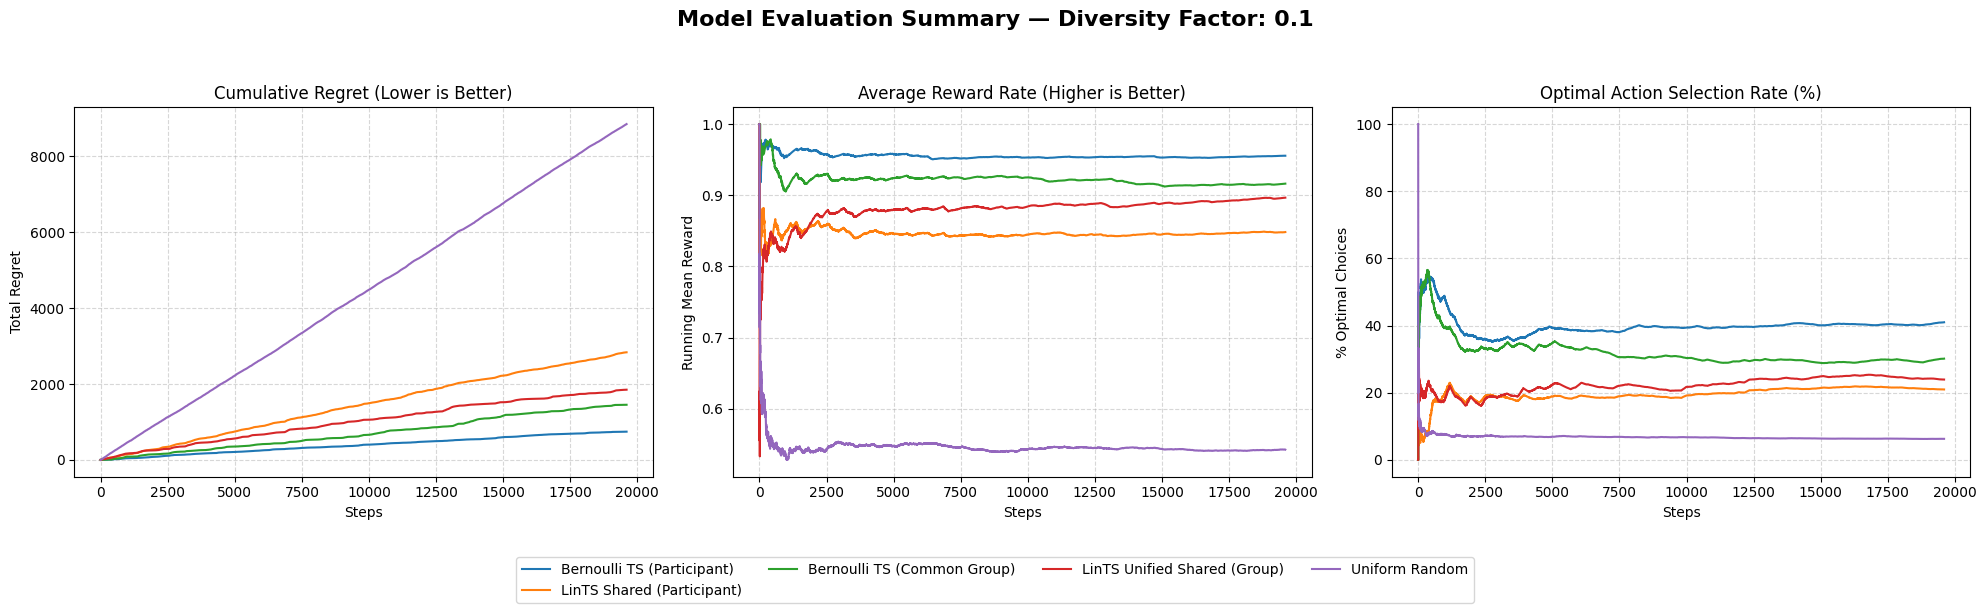

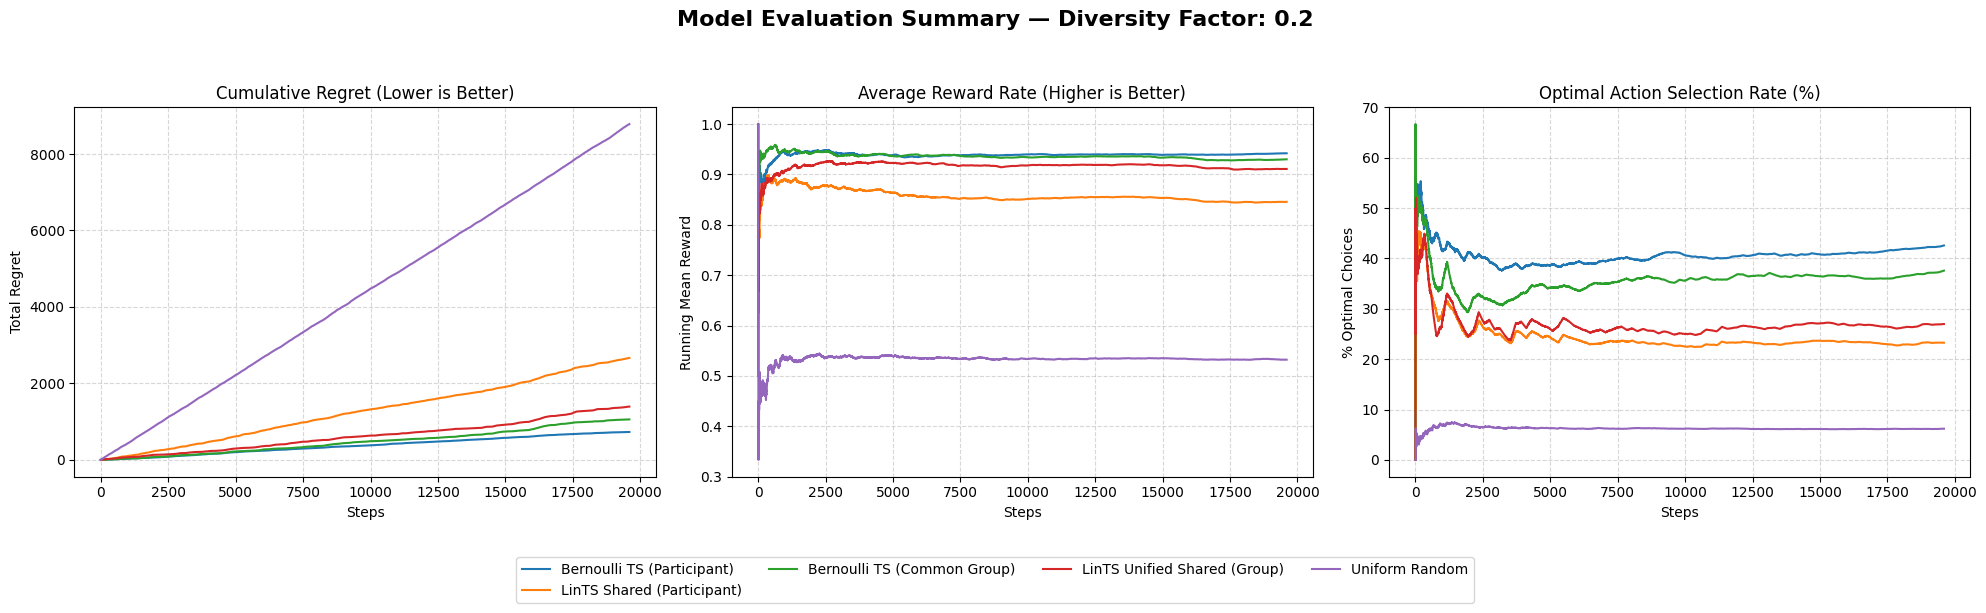

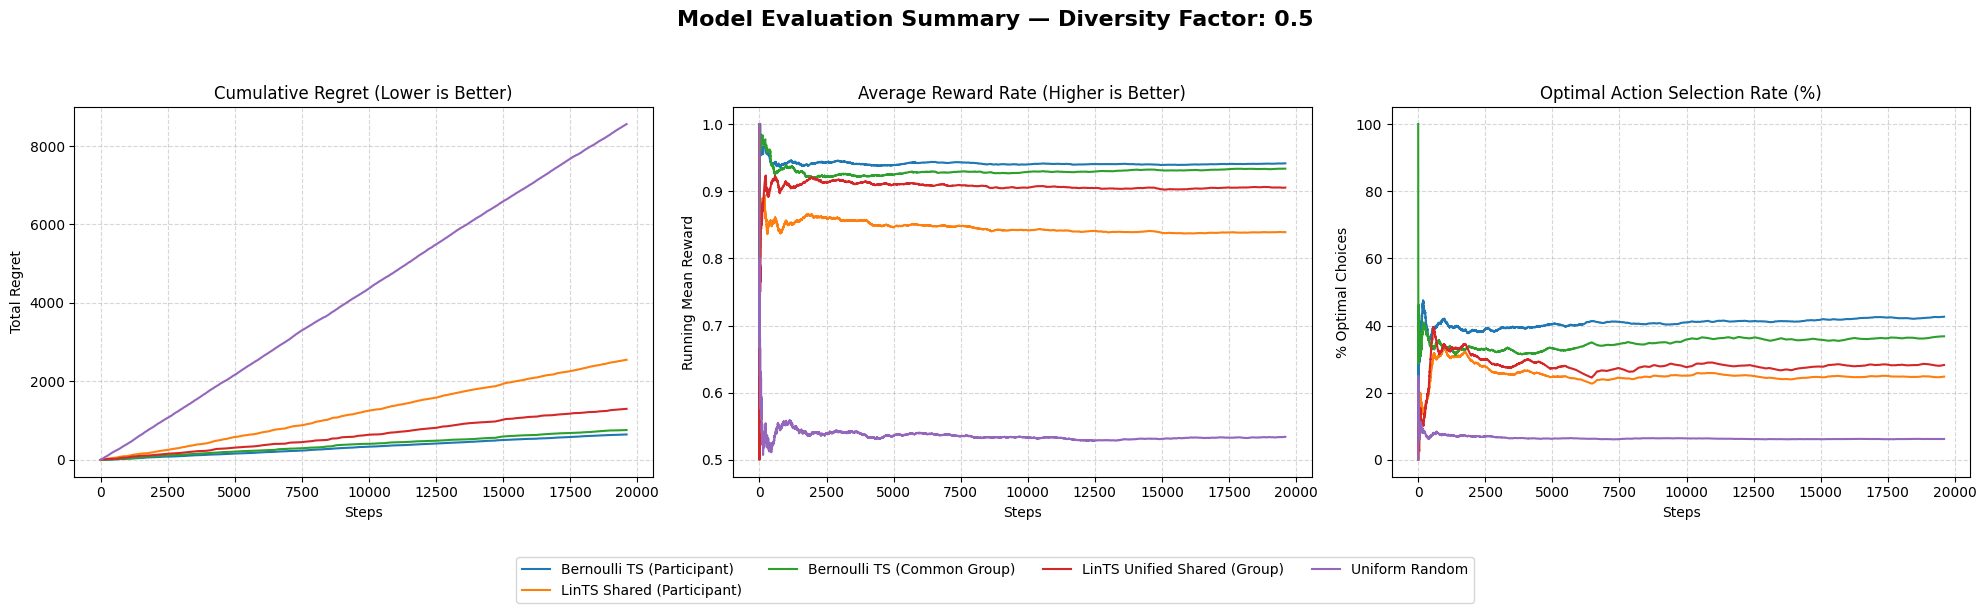

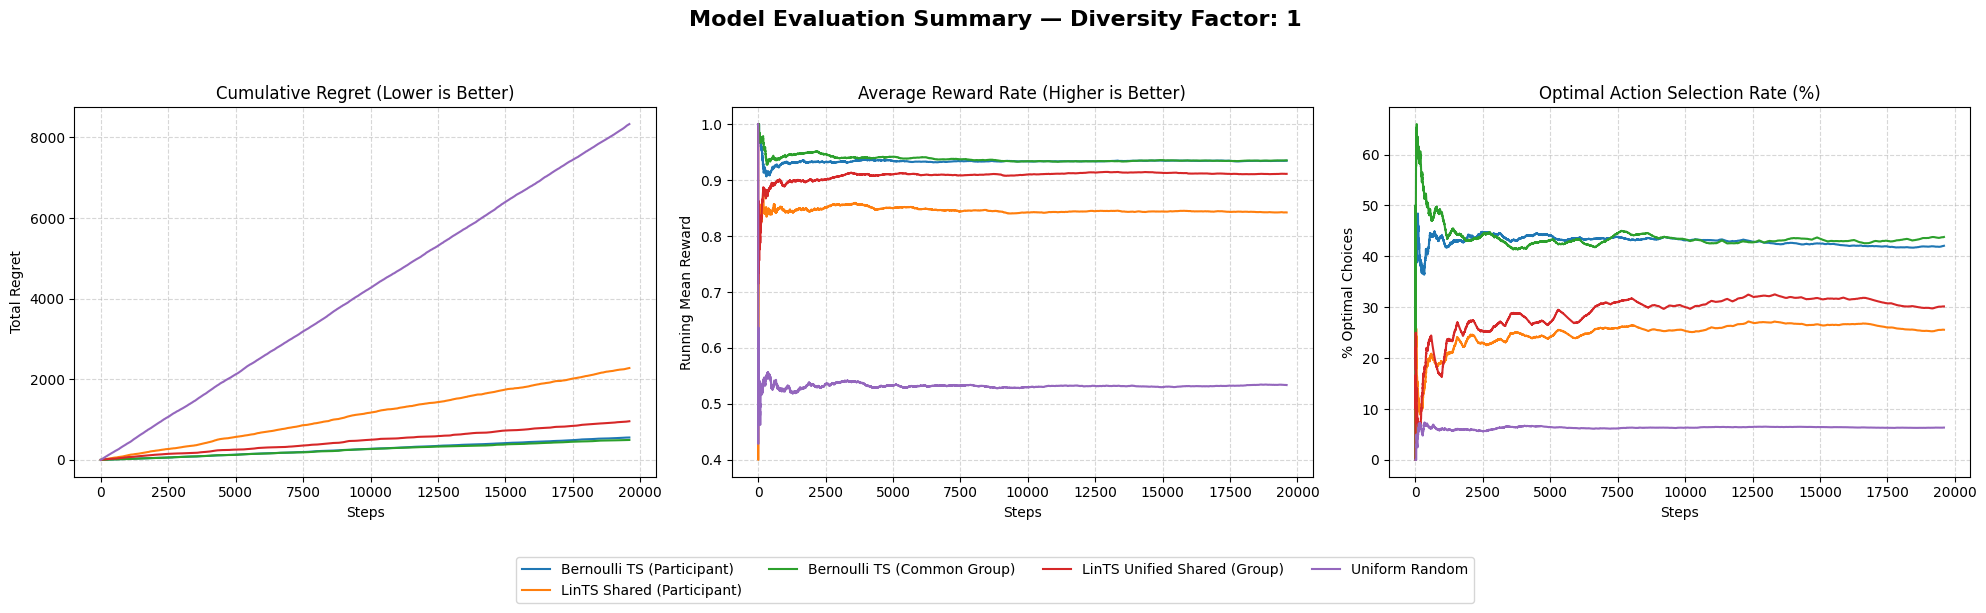

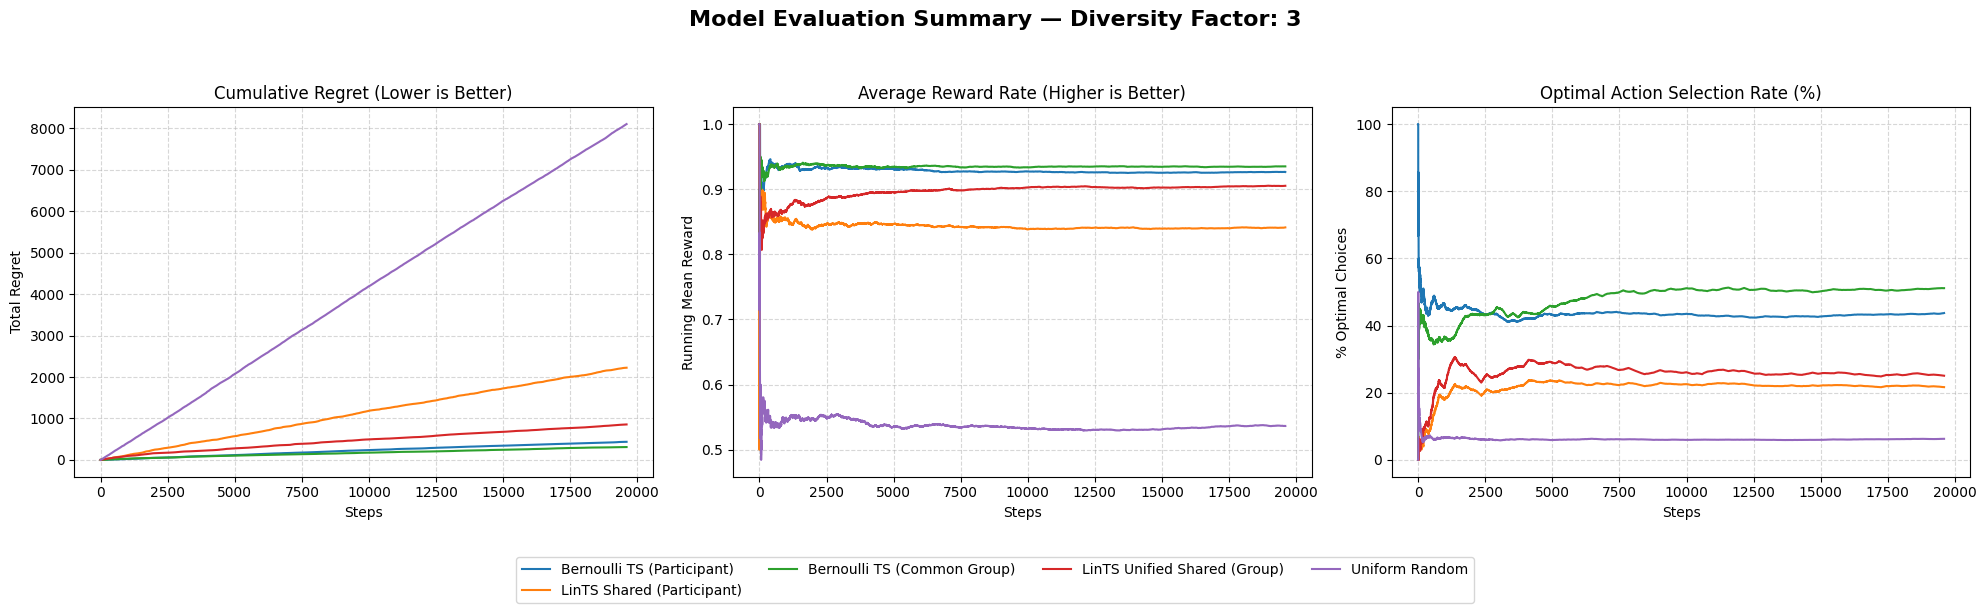

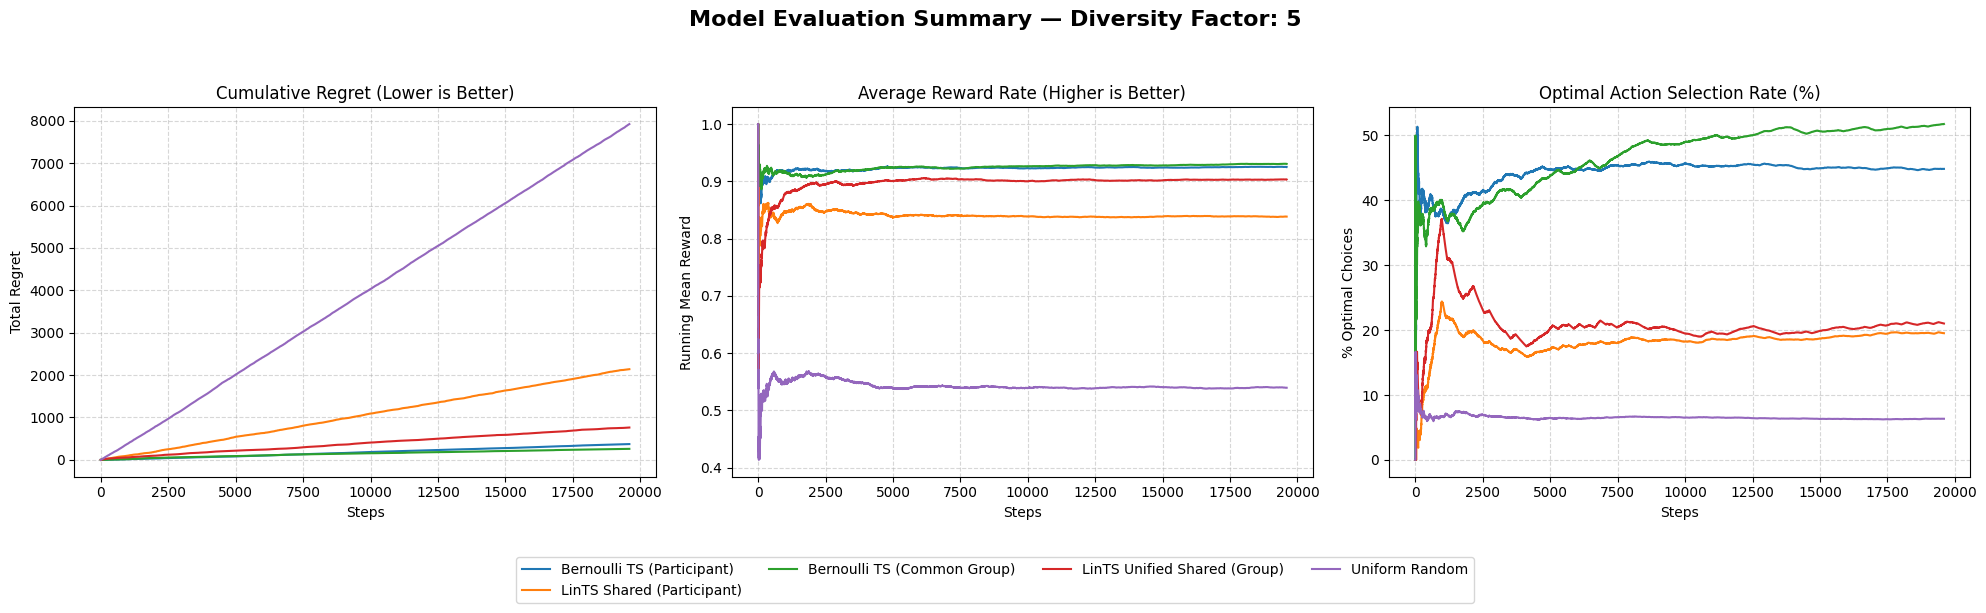

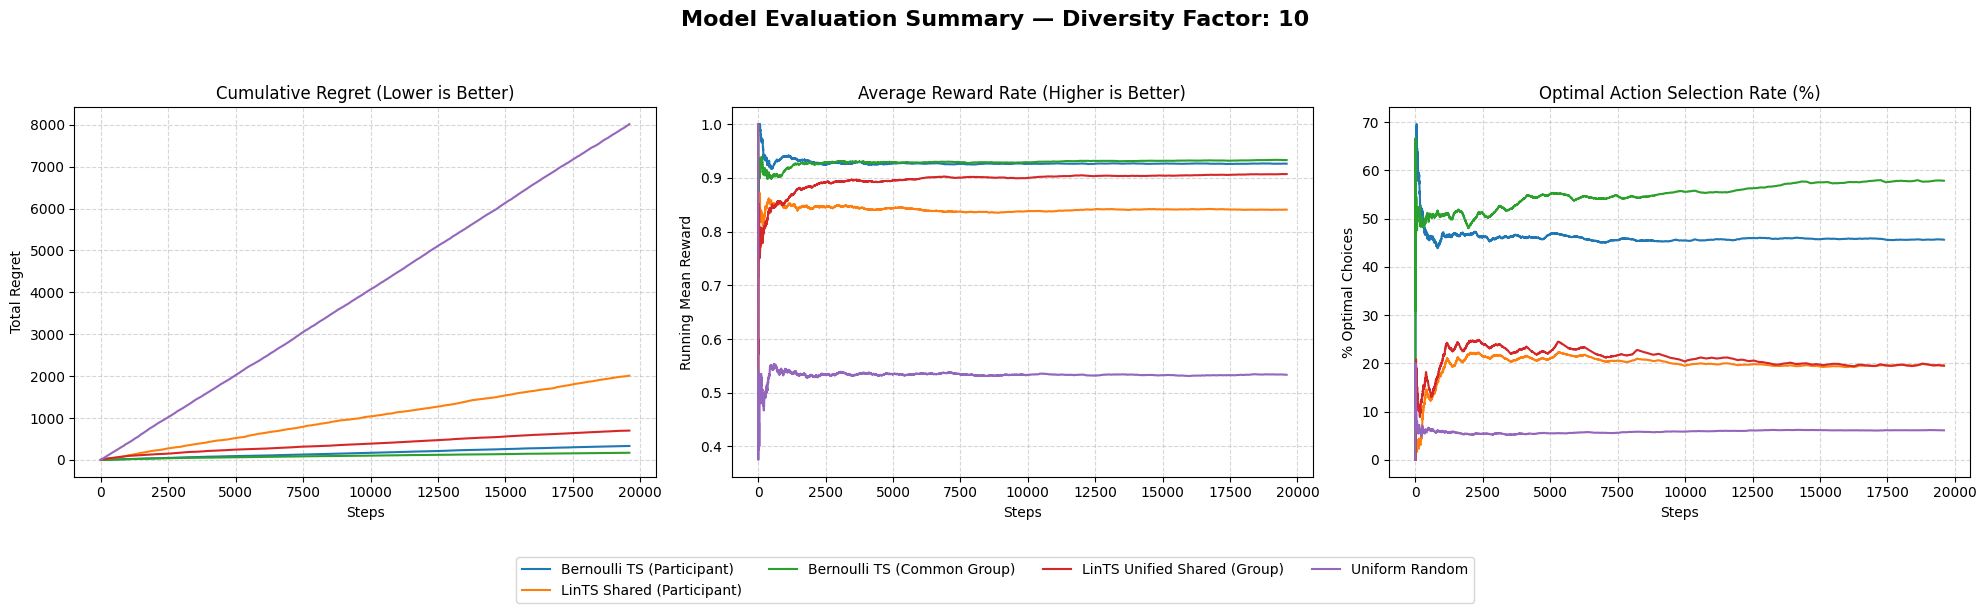

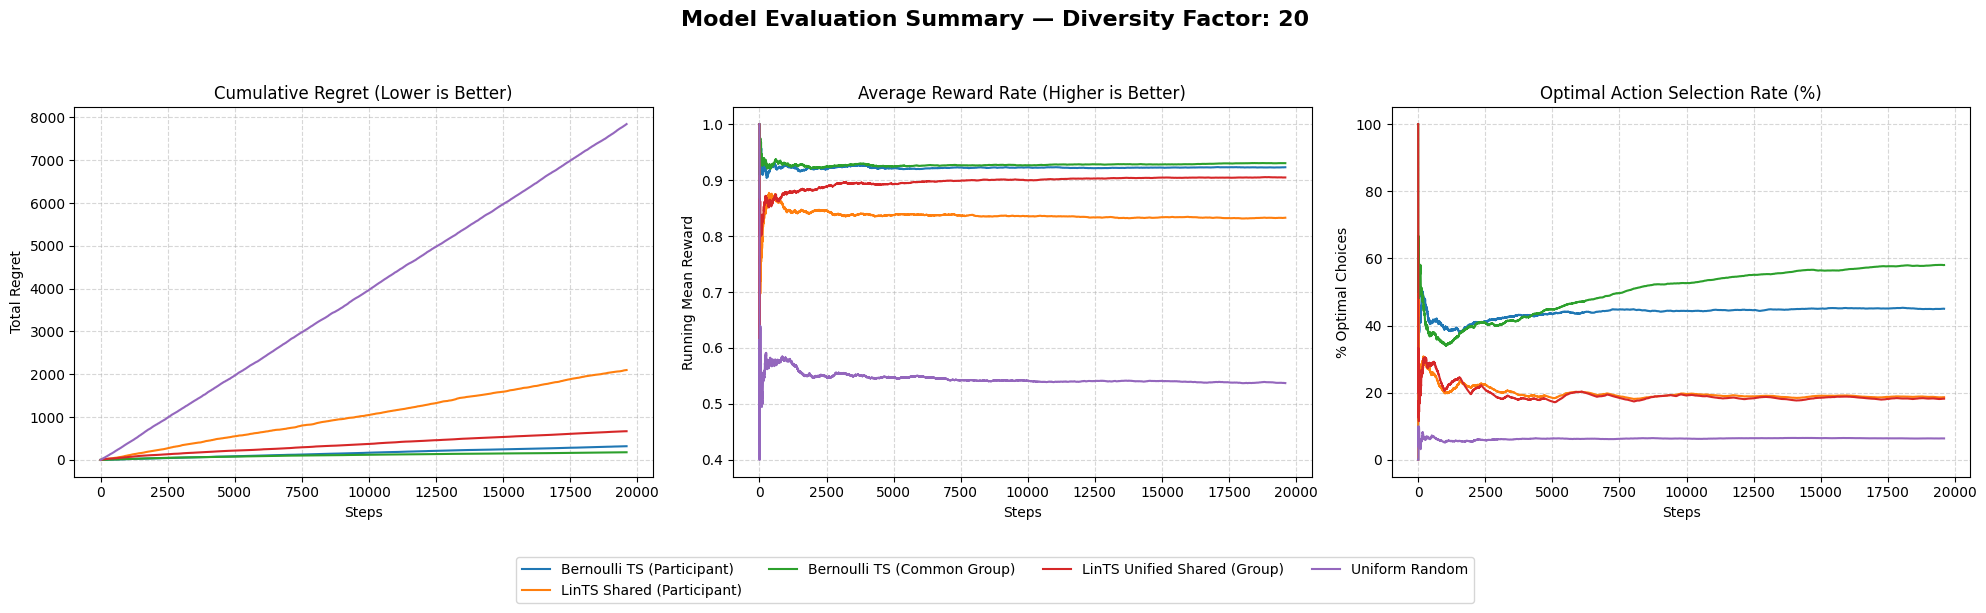

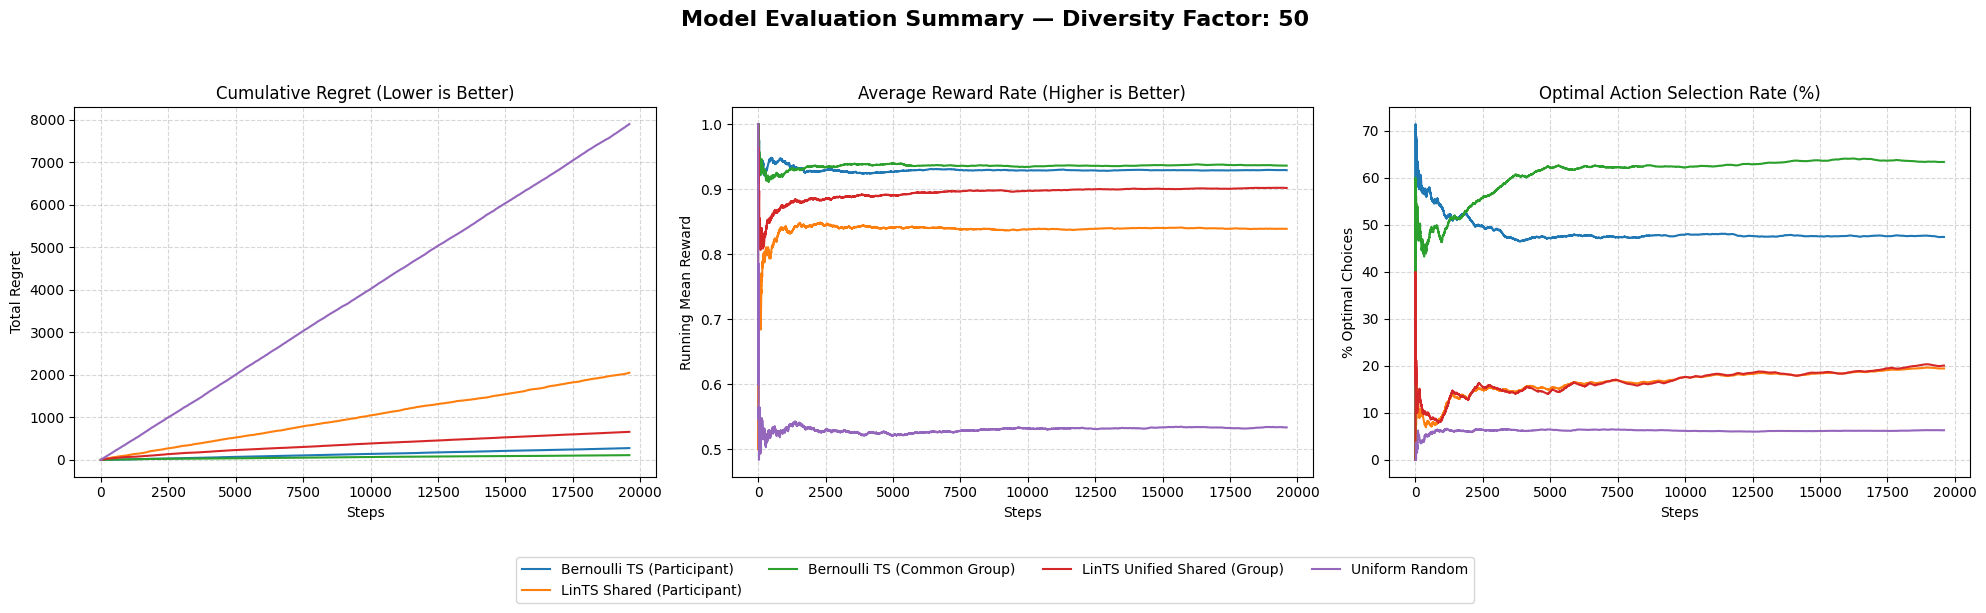

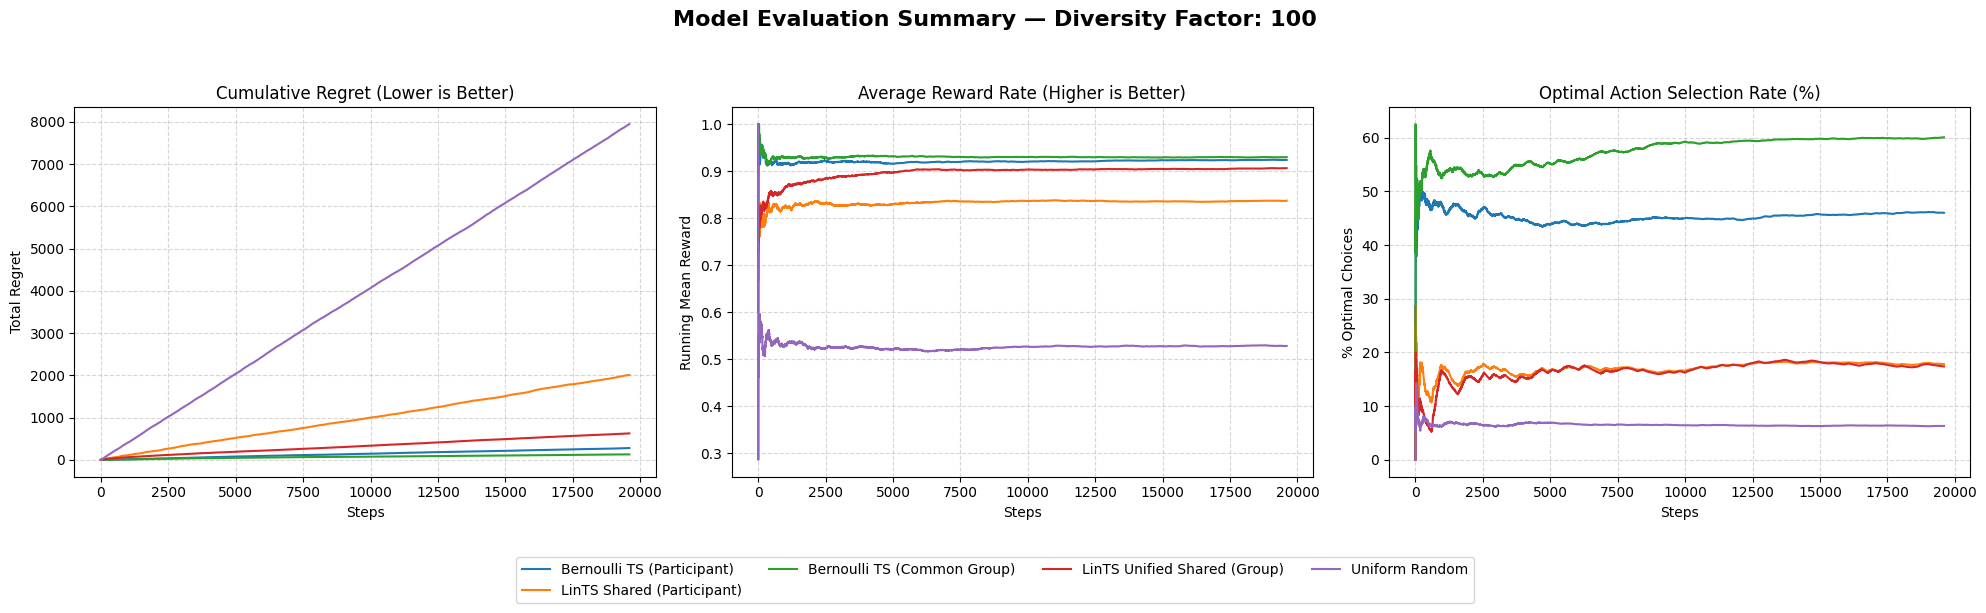

In [141]:
# ---------------------------------------------------------
# 5. Multi-Panel Metric Plotting Pipeline
# ---------------------------------------------------------
for d_factor in diversity_factors:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Model Evaluation Summary — Diversity Factor: {d_factor}", fontsize=16, fontweight='bold', y=1.05)
    
    # Panel 1: Cumulative Regret
    axes[0].set_title("Cumulative Regret (Lower is Better)")
    for m_name in model_names:
        axes[0].plot(grid_history[d_factor][m_name]['regret'], label=m_name)
    axes[0].set_xlabel("Steps")
    axes[0].set_ylabel("Total Regret")
    axes[0].grid(True, linestyle="--", alpha=0.5)
    
    # Panel 2: Average Reward Rate
    axes[1].set_title("Average Reward Rate (Higher is Better)")
    for m_name in model_names:
        axes[1].plot(grid_history[d_factor][m_name]['reward_rate'], label=m_name)
    axes[1].set_xlabel("Steps")
    axes[1].set_ylabel("Running Mean Reward")
    axes[1].grid(True, linestyle="--", alpha=0.5)
    
    # Panel 3: Optimal Action Selection Rate
    axes[2].set_title("Optimal Action Selection Rate (%)")
    for m_name in model_names:
        # Convert to percentage
        axes[2].plot(np.array(grid_history[d_factor][m_name]['opt_rate']) * 100, label=m_name)
    axes[2].set_xlabel("Steps")
    axes[2].set_ylabel("% Optimal Choices")
    axes[2].grid(True, linestyle="--", alpha=0.5)
    
    # Single unified legend placement
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=10)
    
    plt.tight_layout()
    plt.show()

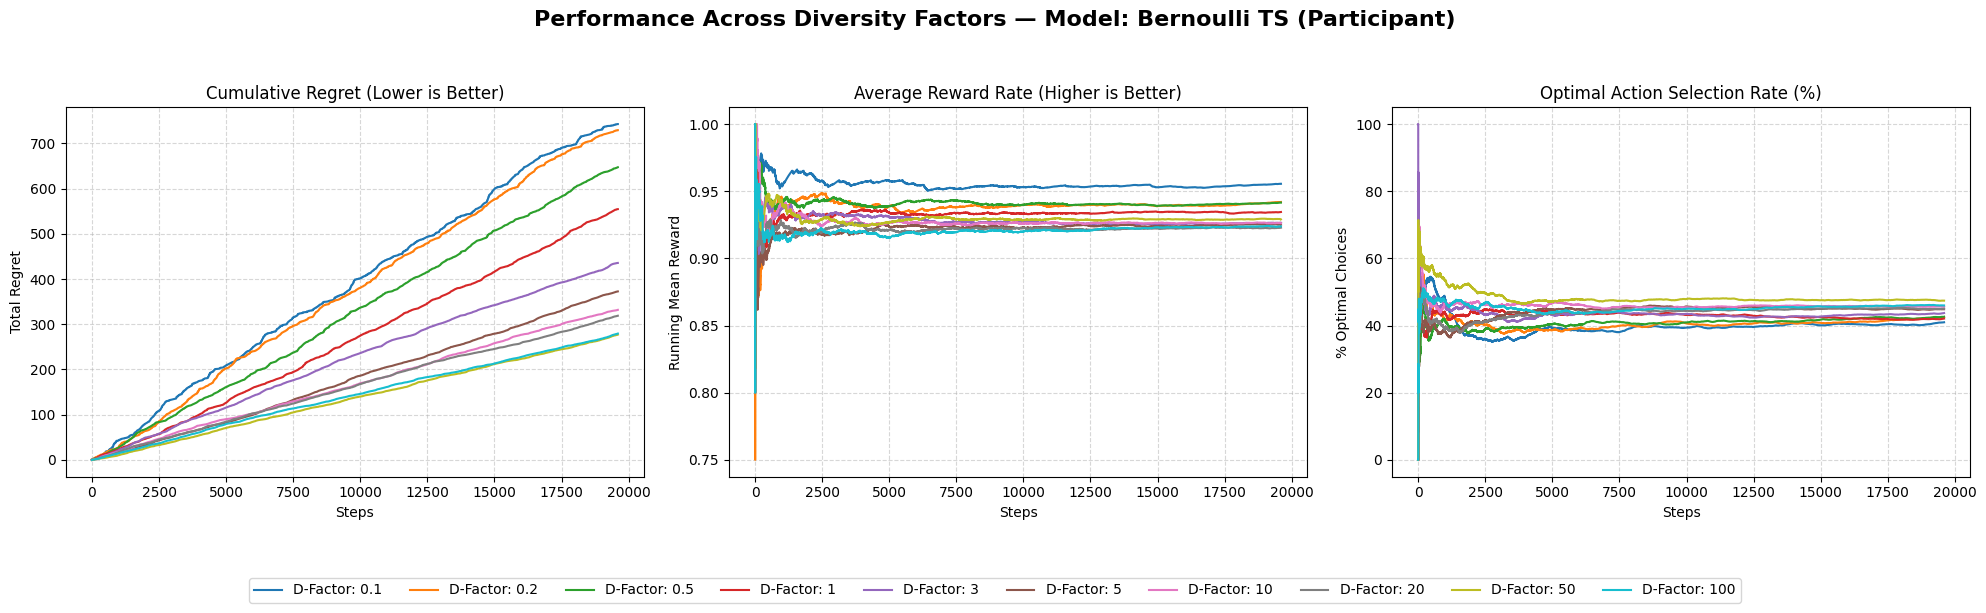

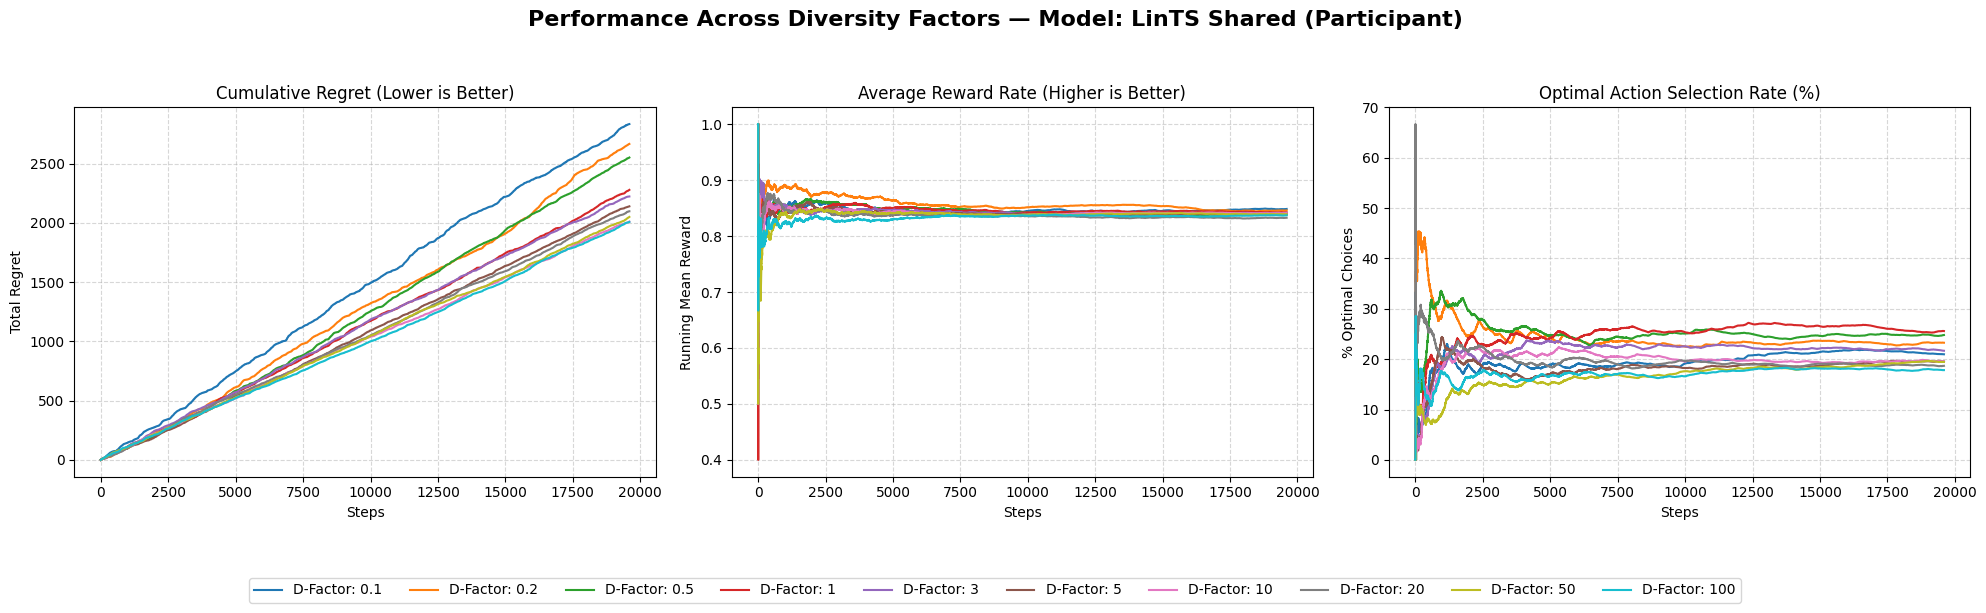

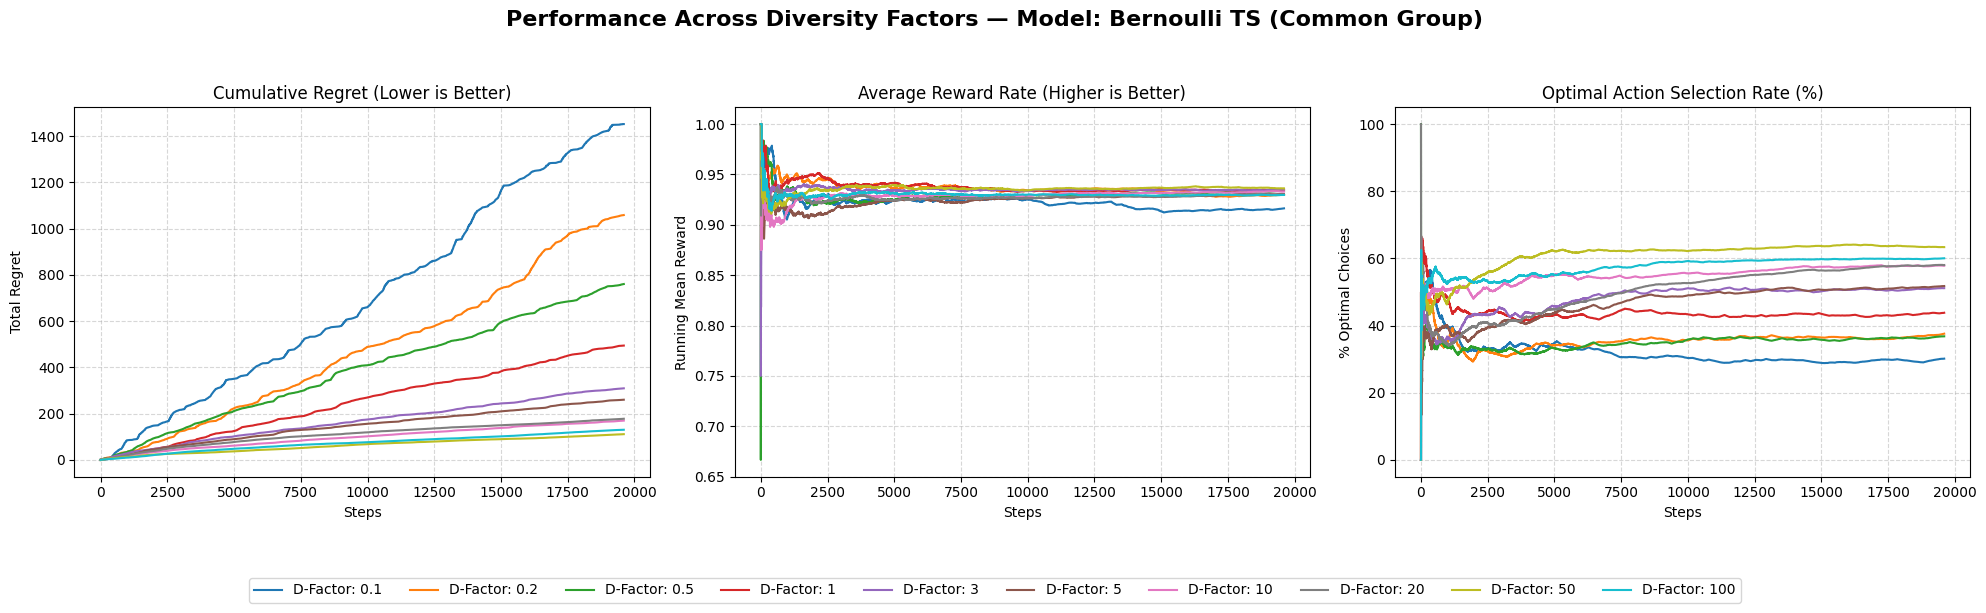

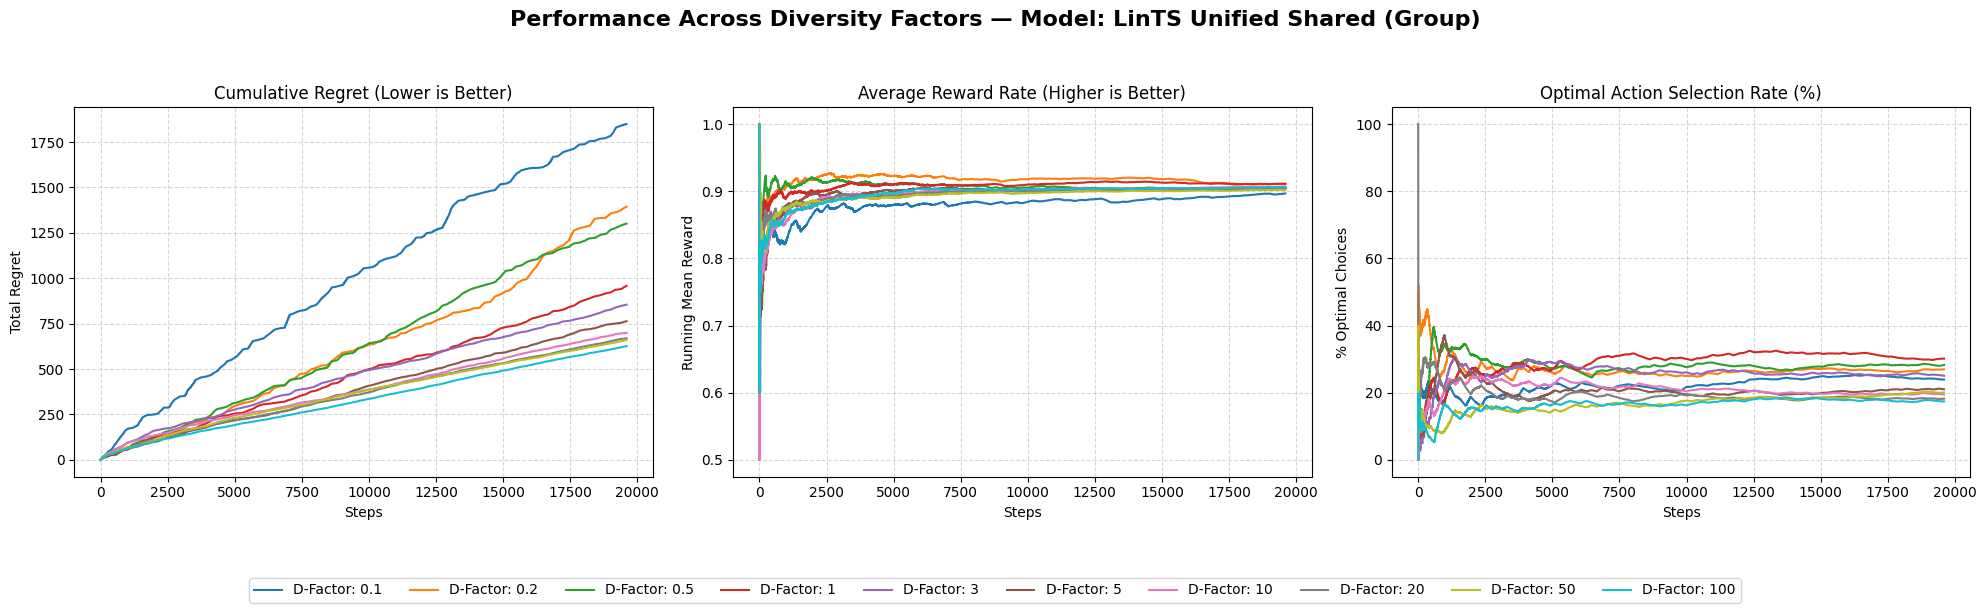

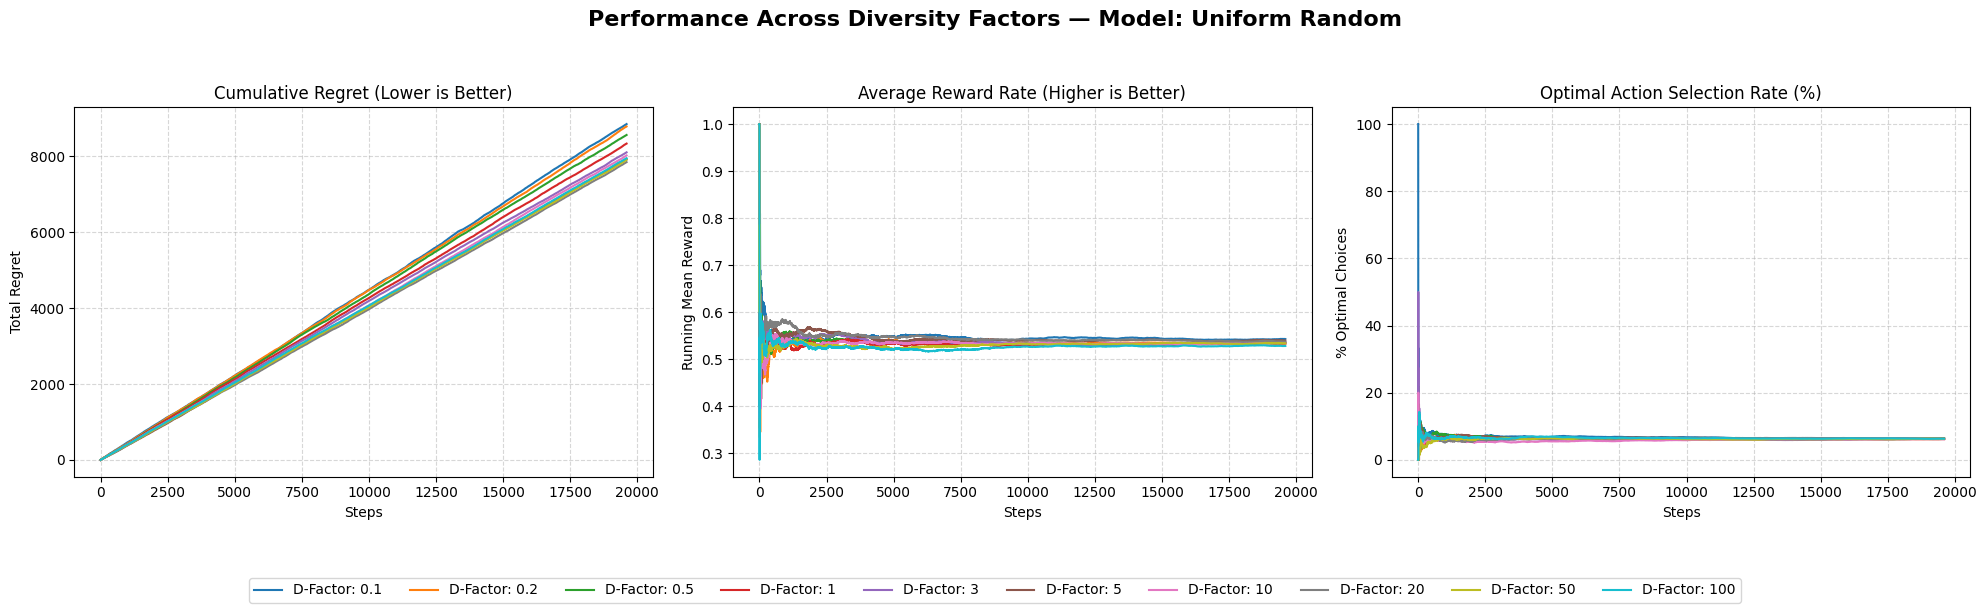

In [142]:
# ---------------------------------------------------------
# 5. Multi-Panel Metric Plotting Pipeline (Model-Centric)
# ---------------------------------------------------------
for m_name in model_names:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Performance Across Diversity Factors — Model: {m_name}", fontsize=16, fontweight='bold', y=1.05)
    
    # Panel 1: Cumulative Regret
    axes[0].set_title("Cumulative Regret (Lower is Better)")
    for d_factor in diversity_factors:
        axes[0].plot(grid_history[d_factor][m_name]['regret'], label=f"D-Factor: {d_factor}")
    axes[0].set_xlabel("Steps")
    axes[0].set_ylabel("Total Regret")
    axes[0].grid(True, linestyle="--", alpha=0.5)
    
    # Panel 2: Average Reward Rate
    axes[1].set_title("Average Reward Rate (Higher is Better)")
    for d_factor in diversity_factors:
        axes[1].plot(grid_history[d_factor][m_name]['reward_rate'], label=f"D-Factor: {d_factor}")
    axes[1].set_xlabel("Steps")
    axes[1].set_ylabel("Running Mean Reward")
    axes[1].grid(True, linestyle="--", alpha=0.5)
    
    # Panel 3: Optimal Action Selection Rate
    axes[2].set_title("Optimal Action Selection Rate (%)")
    for d_factor in diversity_factors:
        # Convert to percentage
        axes[2].plot(np.array(grid_history[d_factor][m_name]['opt_rate']) * 100, label=f"D-Factor: {d_factor}")
    axes[2].set_xlabel("Steps")
    axes[2].set_ylabel("% Optimal Choices")
    axes[2].grid(True, linestyle="--", alpha=0.5)
    
    # Single unified legend placement
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=len(diversity_factors), fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [143]:
# ---------------------------------------------------------
# 6. Ranking Models per Diversity Factor
# ---------------------------------------------------------
print("=== Model Rankings per Diversity Factor ===")

for d_factor in diversity_factors:
    print(f"\nDiversity Factor: {d_factor}")
    print("-" * 50)
    
    # Dictionaries to store the final step's value for each model
    final_regret = {}
    final_reward_rate = {}
    final_opt_rate = {}
    
    for m_name in model_names:
        # We take the final step's value [-1] for the ultimate ranking
        final_regret[m_name] = grid_history[d_factor][m_name]['regret'][-1]
        final_reward_rate[m_name] = grid_history[d_factor][m_name]['reward_rate'][-1]
        final_opt_rate[m_name] = grid_history[d_factor][m_name]['opt_rate'][-1]
        
    # Sort models based on the metrics
    # 1. Cumulative Regret: Lower is better (Ascending sort)
    ranked_by_regret = sorted(final_regret.items(), key=lambda x: x[1])
    
    # 2. Average Reward Rate: Higher is better (Descending sort)
    ranked_by_reward = sorted(final_reward_rate.items(), key=lambda x: x[1], reverse=True)
    
    # 3. Optimal Action Rate: Higher is better (Descending sort)
    ranked_by_opt_rate = sorted(final_opt_rate.items(), key=lambda x: x[1], reverse=True)
    
    # Print the rankings
    print("1. By Cumulative Regret (Lower is Better):")
    for rank, (model, val) in enumerate(ranked_by_regret, 1):
        print(f"   {rank}. {model} (Regret: {val:.4f})")
        
    print("\n2. By Average Reward Rate (Higher is Better):")
    for rank, (model, val) in enumerate(ranked_by_reward, 1):
        print(f"   {rank}. {model} (Reward Rate: {val:.4f})")
        
    print("\n3. By Optimal Action Rate (Higher is Better):")
    for rank, (model, val) in enumerate(ranked_by_opt_rate, 1):
        # Multiply by 100 to display as a percentage matching your plot
        print(f"   {rank}. {model} (Optimal: {val * 100:.2f}%)")
    print("\n")

=== Model Rankings per Diversity Factor ===

Diversity Factor: 0.1
--------------------------------------------------
1. By Cumulative Regret (Lower is Better):
   1. Bernoulli TS (Participant) (Regret: 742.9939)
   2. Bernoulli TS (Common Group) (Regret: 1451.3702)
   3. LinTS Unified Shared (Group) (Regret: 1848.7540)
   4. LinTS Shared (Participant) (Regret: 2833.6720)
   5. Uniform Random (Regret: 8845.1686)

2. By Average Reward Rate (Higher is Better):
   1. Bernoulli TS (Participant) (Reward Rate: 0.9555)
   2. Bernoulli TS (Common Group) (Reward Rate: 0.9163)
   3. LinTS Unified Shared (Group) (Reward Rate: 0.8966)
   4. LinTS Shared (Participant) (Reward Rate: 0.8483)
   5. Uniform Random (Reward Rate: 0.5429)

3. By Optimal Action Rate (Higher is Better):
   1. Bernoulli TS (Participant) (Optimal: 40.97%)
   2. Bernoulli TS (Common Group) (Optimal: 30.14%)
   3. LinTS Unified Shared (Group) (Optimal: 23.92%)
   4. LinTS Shared (Participant) (Optimal: 20.97%)
   5. Uniform Ran